In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys

sys.path.append(r"D:/Football Project/src")

import feature_lists_v2 as fl


In [196]:
df = pd.read_csv("../../../data/processed/v2/strikers_top5leagues_sofascore2526.csv")

In [197]:
X=df.drop(columns=fl.metadata_features)

In [198]:
metadata=df[fl.metadata_features]

In [199]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [200]:
inertia = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_scaled)
    inertia.append(km.inertia_)

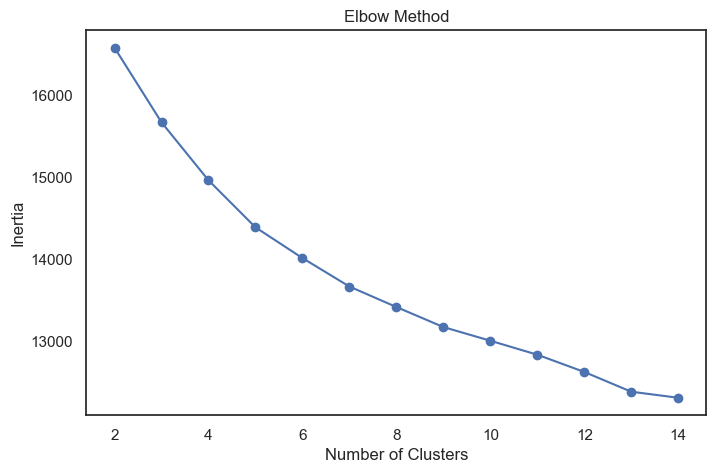

In [201]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [202]:
scores = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

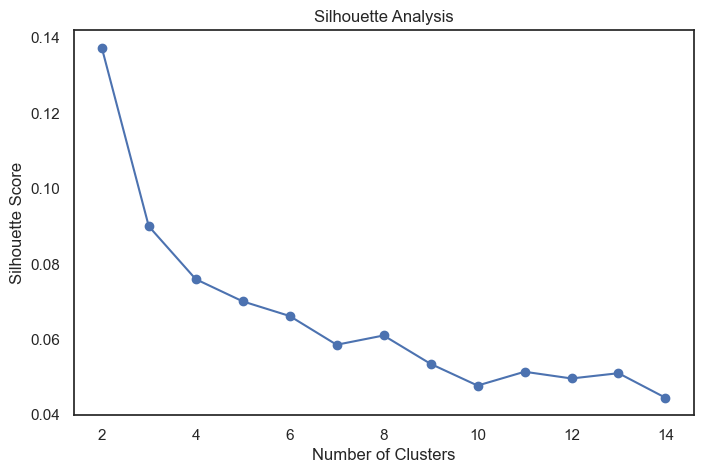

In [203]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [204]:
x=4
kmeans = KMeans(
    n_clusters=x,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_scaled)

df[f"cluster_{x}"] = labels



In [205]:
cluster_summary = (df.drop(columns=fl.metadata_features).groupby("cluster_4").mean())

display(cluster_summary.transpose())

cluster_4,0,1,2,3
accurateCrossesPercentage,24.106765,15.336043,23.029426,17.997059
accurateLongBallsPercentage,58.671176,53.432518,50.507787,54.795059
aerialDuelsWonPercentage,32.791324,39.551295,31.847705,43.320706
goalConversionPercentage,12.511912,11.859137,8.885082,19.774706
groundDuelsWonPercentage,46.986912,39.355899,44.890082,40.408588
offsides,4.205882,8.928058,4.377049,10.905882
successfulDribblesPercentage,46.624118,38.253597,41.952459,44.838706
totalDuelsWonPercentage,45.592059,39.973597,42.624590,41.697176
goals_per90,0.313371,0.260243,0.185331,0.578064
expectedGoals_per90,0.287247,0.326595,0.206387,0.540622


In [206]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:,0]
df["PC2"] = X_pca[:,1]

fig = px.scatter(
    df,
    x="PC1",
    y="PC2",
    color="cluster_4",
    hover_name='player',         
    hover_data=['team',], 
    title="Striker Clusters (K=4)",
    width=1000,
    height=700
)

fig.show()

In [207]:
df["cluster_4"].value_counts().sort_index()

cluster_4
0     68
1    139
2    122
3     85
Name: count, dtype: int64

In [208]:
from scipy.spatial.distance import cdist

distances = cdist(X_scaled, kmeans.cluster_centers_)

for cluster in range(4):

    members = df[df["cluster_4"] == cluster]

    member_idx = members.index

    d = distances[member_idx, cluster]

    closest_idx = member_idx[np.argsort(d)[:10]]

    print(df.loc[closest_idx, ["player","team"]])

                  player                    team
6       Leandro Trossard                 Arsenal
11      Samuel Chukwueze                  Fulham
241    Christian Pulišić                AC Milan
226         Kenan Yıldız                Juventus
232         Matías Soulé                 AS Roma
361        Ibrahim Mbaye     Paris Saint-Germain
345         Amine Gouiri  Olympique de Marseille
82        Julián Alvarez         Atlético Madrid
32          Jacob Murphy        Newcastle United
235  Sebastiano Esposito                Cagliari
                   player            team
131     Roberto Fernández        Espanyol
294          Duván Zapata          Torino
292        Walid Cheddira           Lecce
306       Lorenzo Colombo           Genoa
406          Ally Samatta        Le Havre
137        Gorka Guruzeta   Athletic Club
298          Caleb Ekuban           Genoa
73   Jørgen Strand Larsen  Crystal Palace
264          Kieron Bowie   Hellas Verona
314        Thijs Dallinga         Bologna

In [209]:
cluster_summary = (
    df
    .groupby("cluster_4")["goals_per90"]
    .rank(pct=True)
)

In [210]:
display(cluster_summary)

0      0.929412
1      0.485294
2      0.364706
3      0.909836
4      0.811475
         ...   
409    0.426230
410    0.086066
411    0.258993
412    0.294964
413    0.039568
Name: goals_per90, Length: 414, dtype: float64

In [211]:
px.parallel_coordinates(
    df,
    color="cluster_4",
    dimensions=[
        "goals_per90",
        "assists_per90",
        "keyPasses_per90",
        "successfulDribbles_per90",
        "aerialDuelsWon_per90"
    ]
)

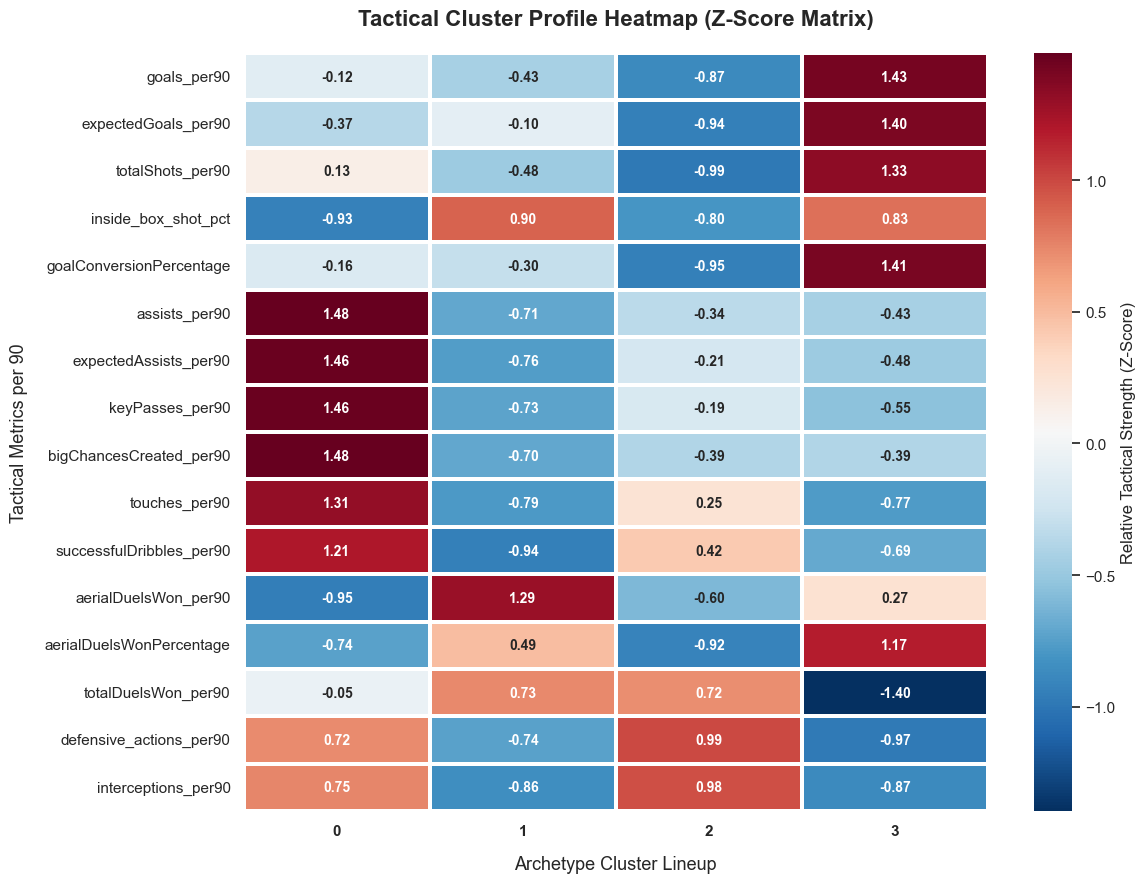

In [212]:
heatmap_features = [
    "goals_per90",
    "expectedGoals_per90",
    "totalShots_per90",
    "inside_box_shot_pct",
    "goalConversionPercentage",
    "assists_per90",
    "expectedAssists_per90",
    "keyPasses_per90",
    "bigChancesCreated_per90",
    "touches_per90",
    "successfulDribbles_per90",
    "aerialDuelsWon_per90",
    "aerialDuelsWonPercentage",
    "totalDuelsWon_per90",
    "defensive_actions_per90",
    "interceptions_per90"
]

cluster_means = df.groupby("cluster_4")[heatmap_features].mean()
cluster_zscores = cluster_means.apply(lambda x: (x - x.mean()) / x.std(), axis=0).T

plt.figure(figsize=(12, 9))
sns.set_theme(style="white")

sns.heatmap(
    cluster_zscores, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r", 
    linewidths=1.5, 
    linecolor="white",
    cbar_kws={'label': 'Relative Tactical Strength (Z-Score)'},
    annot_kws={"size": 10, "weight": "bold"}
)

plt.title("Tactical Cluster Profile Heatmap (Z-Score Matrix)", fontsize=16, pad=20, weight='bold')
plt.xlabel("Archetype Cluster Lineup", fontsize=13, labelpad=12)
plt.ylabel("Tactical Metrics per 90", fontsize=13, labelpad=12)
plt.xticks(fontsize=11, weight='bold')
plt.yticks(fontsize=11)
plt.tight_layout()

plt.show()

In [213]:
cluster_names = {
    0: "Creative Wide Forward",
    1: "Target Man",
    2: "Mobile Support Forward",
    3: "Elite Finisher"
}

df["cluster_name"] = df["cluster_4"].map(cluster_names)

In [214]:
pca = PCA()

X_pca_full = pca.fit_transform(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

In [215]:
var_df = pd.DataFrame({
    "Components": range(1, len(cum_var)+1),
    "Cumulative Variance": cum_var
})

px.line(
    var_df,
    x="Components",
    y="Cumulative Variance",
    title="PCA Explained Variance"
).show()

In [216]:
pca_sizes = [5,10, 15, 20, 25]

pca_datasets = {}

for n in pca_sizes:
    pca = PCA(n_components=n, random_state=42)
    pca_datasets[n] = pca.fit_transform(X_scaled)

In [217]:
results = []

for n_comp, X_pca in pca_datasets.items():

    for k in range(2, 11):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)

        results.append(
            {
                "n_components": n_comp,
                "k": k,
                "silhouette": sil
            }
        )

In [218]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,k,silhouette
0,5,2,0.264290
1,5,3,0.197633
9,10,2,0.195410
3,5,5,0.173549
2,5,4,0.172016
5,5,7,0.169782
4,5,6,0.168968
18,15,2,0.167867
7,5,9,0.165799
6,5,8,0.160526


In [219]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns.tolist(),
    columns=[f"PC{i+1}" for i in range(5)]
)

loadings

,PC1,PC2,PC3,PC4,PC5
accurateCrossesPercentage,0.064586,0.023720,-0.057134,0.068111,0.029433
accurateLongBallsPercentage,0.014353,0.098402,0.004143,-0.002042,0.018607
aerialDuelsWonPercentage,-0.106013,0.065338,0.249041,-0.142047,-0.084895
goalConversionPercentage,-0.114742,0.258521,-0.024160,-0.050920,0.259429
groundDuelsWonPercentage,0.188164,0.061873,0.178500,-0.260495,0.024552
offsides,-0.144432,0.085664,0.089998,0.053601,0.005923
successfulDribblesPercentage,0.070893,0.104850,0.070873,-0.075031,0.132430
totalDuelsWonPercentage,0.131951,0.091443,0.311949,-0.280792,-0.035869
goals_per90,-0.116308,0.338906,0.070807,0.003143,0.233615
expectedGoals_per90,-0.169212,0.294056,0.125071,0.042032,0.049419


In [220]:
for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))


PC1
touches_per90               0.287939
groundDuelsWon_per90        0.246343
defensive_actions_per90     0.236072
expectedAssists_per90       0.230693
possessionLost_per90        0.229769
keyPasses_per90             0.226794
successfulDribbles_per90    0.224022
accurateCrosses_per90       0.222153
inside_box_shot_pct         0.209683
aerialLost_per90            0.194976
Name: PC1, dtype: float64

PC2
goals_per90                  0.338906
expectedGoals_per90          0.294056
duelLost_per90               0.278590
goalConversionPercentage     0.258521
totalShots_per90             0.246242
penaltyGoals_per90           0.232926
possession_lost_per_touch    0.225228
aerialLost_per90             0.177609
shots_on_target_pct          0.174335
bigChancesCreated_per90      0.169653
Name: PC2, dtype: float64

PC3
totalDuelsWon_per90         0.426613
aerialDuelsWon_per90        0.319580
totalDuelsWonPercentage     0.311949
shotsOffTarget_per90        0.254663
aerialDuelsWonPercentage    0.24904

In [221]:
print(pca.explained_variance_ratio_.sum())

0.5113029458400677


In [222]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(5)]
)

In [223]:
results=[]
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_pca)

    results.append({
        "k": k,
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": kmeans.inertia_
    })

df_results = pd.DataFrame(results)

In [224]:
px.line(
    df_results,
    x="k",
    y="inertia",
    markers=True,
    title="Elbow Method"
).show()

px.line(
    df_results,
    x="k",
    y="silhouette",
    markers=True,
    title="Silhouette Score"
).show()

In [225]:
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=20)
df['pca_cluster_4'] = kmeans_pca.fit_predict(X_pca)

In [226]:
cluster_summary = (df.drop(columns=fl.metadata_features+['cluster_4','PC1','PC2','cluster_name',]).groupby("pca_cluster_4").mean())

display(cluster_summary.transpose())

pca_cluster_4,0,1,2,3
accurateCrossesPercentage,17.300846,22.158235,16.634216,23.804625
accurateLongBallsPercentage,54.571538,48.000294,53.424412,59.958375
aerialDuelsWonPercentage,38.167923,32.189412,43.131275,33.132250
goalConversionPercentage,16.979615,8.060980,11.630980,13.101625
groundDuelsWonPercentage,38.483692,44.635392,41.600588,47.224375
offsides,9.615385,3.843137,8.970588,5.387500
successfulDribblesPercentage,40.408846,41.862745,40.771667,46.691500
totalDuelsWonPercentage,38.697462,42.471961,42.858431,45.833500
goals_per90,0.435864,0.157646,0.285471,0.342107
expectedGoals_per90,0.435861,0.181844,0.354872,0.308182


In [227]:
df["PC1"] = X_pca[:,0]
df["PC2"] = X_pca[:,1]

fig = px.scatter(
    df,
    x="PC1",
    y="PC2",
    color="pca_cluster_4",
    hover_name='player',         
    hover_data=['team',], 
    title="Striker Clusters (K=4)",
    width=1000,
    height=700
)

fig.show()

In [229]:
distances = cdist(X_pca, kmeans_pca.cluster_centers_)

for cluster in range(4):

    members = df[df["pca_cluster_4"] == cluster]

    member_idx = members.index

    d = distances[member_idx, cluster]

    closest_idx = member_idx[np.argsort(d)[:20]]

    print(df.loc[closest_idx, ["player","team"]])

                   player                team
315            Gift Orban       Hellas Verona
30   Valentín Castellanos     West Ham United
216          Tim Lemperle      TSG Hoffenheim
120              Rafa Mir               Elche
367       Folarin Balogun           AS Monaco
12          Ollie Watkins         Aston Villa
201     Dženan Pejčinović       VfL Wolfsburg
18           Ismaïla Sarr      Crystal Palace
394     Goduine Koyalipou              Angers
305      Andrea Pinamonti            Sassuolo
84        Jorge de Frutos      Rayo Vallecano
353            Pavel Šulc  Olympique Lyonnais
282           Jamie Vardy           Cremonese
34           Lukas Nmecha        Leeds United
204       Budu Zivzivadze    1. FC Heidenheim
376         Aiyegun Tosin             Lorient
41          Donyell Malen         Aston Villa
49              Evanilson         Bournemouth
177          Oliver Burke  1. FC Union Berlin
124         Borja Mayoral              Getafe
                  player          

In [233]:
from scipy.spatial.distance import pdist, squareform

centroids = kmeans_pca.cluster_centers_
distances = squareform(pdist(centroids))
print(distances)

[[0.         5.67725772 3.67631267 6.61727209]
 [5.67725772 0.         4.75492015 4.27385678]
 [3.67631267 4.75492015 0.         6.64413269]
 [6.61727209 4.27385678 6.64413269 0.        ]]


In [237]:
df['cluster_name'].unique()

<StringArray>
[        'Elite Finisher',  'Creative Wide Forward', 'Mobile Support Forward',
             'Target Man']
Length: 4, dtype: str

In [238]:
cluster_names = {
    0: "Elite Finisher",
    1: "Mobile Support Forward",
    2: "Target Man",
    3: "Playmaking Attacker"
}

df["cluster_name"] = df["cluster_4"].map(cluster_names)

In [241]:
df=df.drop(columns=['cluster_4',
 'PC1',
 'PC2',])

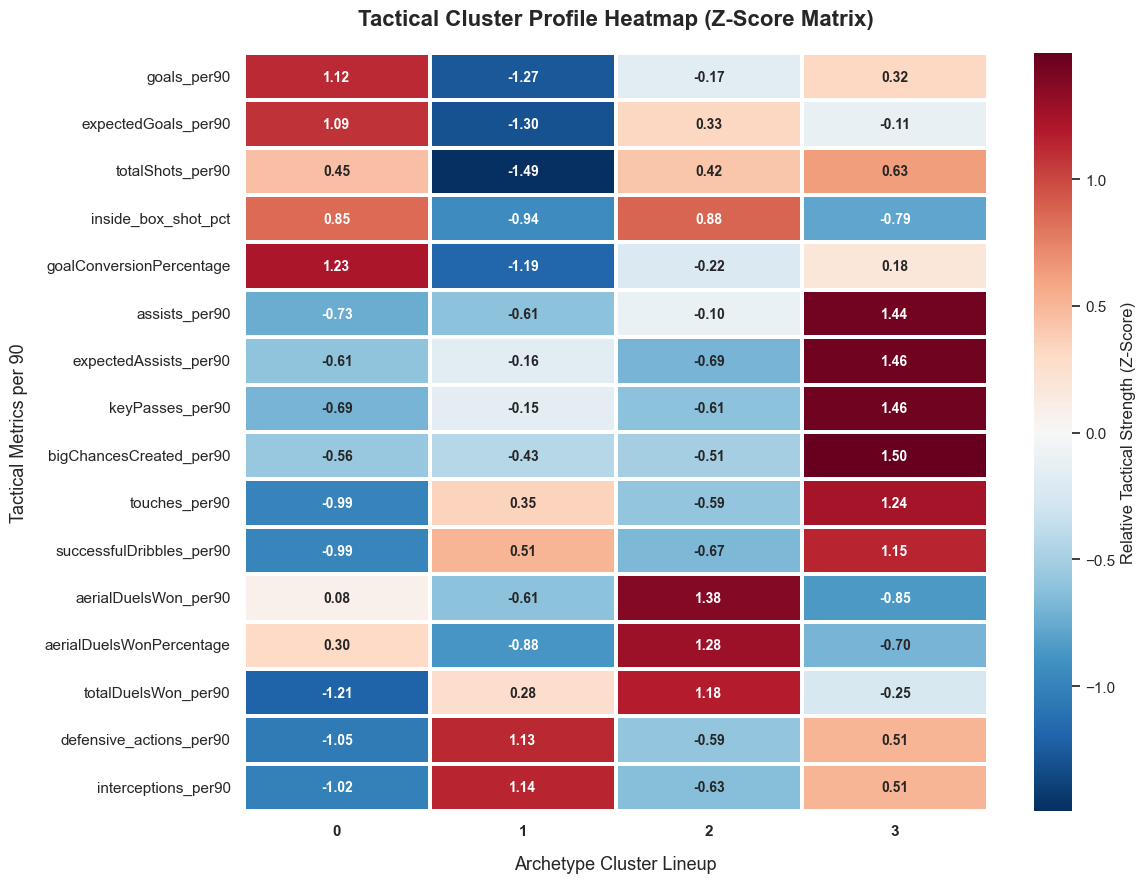

In [244]:
cluster_means = df.groupby("pca_cluster_4")[heatmap_features].mean()
cluster_zscores = cluster_means.apply(lambda x: (x - x.mean()) / x.std(), axis=0).T

plt.figure(figsize=(12, 9))
sns.set_theme(style="white")

sns.heatmap(
    cluster_zscores, 
    annot=True, 
    fmt=".2f", 
    cmap="RdBu_r", 
    linewidths=1.5, 
    linecolor="white",
    cbar_kws={'label': 'Relative Tactical Strength (Z-Score)'},
    annot_kws={"size": 10, "weight": "bold"}
)

plt.title("Tactical Cluster Profile Heatmap (Z-Score Matrix)", fontsize=16, pad=20, weight='bold')
plt.xlabel("Archetype Cluster Lineup", fontsize=13, labelpad=12)
plt.ylabel("Tactical Metrics per 90", fontsize=13, labelpad=12)
plt.xticks(fontsize=11, weight='bold')
plt.yticks(fontsize=11)
plt.tight_layout()

plt.show()

### Harry Kane and Kylian Mbappe have overperformed so much that they have become Outliers ###

### I Conclude that using a Time Weighted Average is better to remove Anomolies and getting a more consistent result ###